In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split as train_test_split_s
import seaborn as sns

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))
from config import *
from src.models import *
from src.dataset import *
from utils import *

# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"    # ?

set_seed(seed=GLOBAL_SEED)

2025-07-25 12:34:47.770020: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-25 12:34:47.802253: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-25 12:34:48.253591: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
WINDOW_SIZE = 52
CHANNELS = [0, 1, 2, 3, 4, 5, 6, 7]
FOLD_ID = 1

GESTURE_NAMES = ['Rest', 'Thumb up', 'Flexion of ring\nand little finger,\nextension of the others',
                 'Fingers flexed\ntogether in fist', 'Pointing index', 'Medium wrap',
                 'Writing tripod\ngrasp', 'Prismatic pinch\ngrasp', 'Lateral grasp']

## Вспомогательные функции для предобработки датасета

> Warning: Нужно выбирать `CHANNELS` как гиперпараметр.

In [3]:
def standardize(X, means, stds):
    return (X - means[None,:,None]) / stds[None,:,None]

In [4]:
def prepare(X, channels=CHANNELS):
    Xt = np.transpose(X, (0, 2, 1))   # [N, window, channels]
    sel = Xt[..., channels]           # отбор каналов
    return sel[..., np.newaxis].astype(np.float32)

def prepare_1d(X, channels=CHANNELS):
    Xt = np.transpose(X, (0, 2, 1))   # [N, window, channels]
    Xt = Xt[..., channels]   
    return Xt.astype(np.float32)

In [5]:
def train_model(model, epochs, X_train, y_train, X_valid, y_valid, batch_size=BATCH_SIZE, lr=INIT_LR, decay_rate=0.9,
                save_path=None, patience=PATIENCE):
    callbacks = [tf.keras.callbacks.EarlyStopping('val_loss', mode='min', patience=patience)]
    if save_path:
        callbacks.append(
            tf.keras.callbacks.ModelCheckpoint(
                save_path, monitor='val_loss',
                save_best_only=True, save_weights_only=False,    # Сохранять всю архитектуру
                mode='min', verbose=1
            )
        )
    steps = (len(X_train) / batch_size) * 1.5
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        lr, decay_steps=steps, decay_rate=decay_rate
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss='sparse_categorical_crossentropy', metrics=['accuracy']
    )
    return model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1  # прогресс-бар
    )

## Парсинг данных

Данные парсятся из собранного датасета. Изменить номер фолда можно через переменную `FOLD_ID`. 

In [6]:
gestures_dict = {}

for idx in GESTURE_INDEXES_MAIN:
    gestures_dict[f'{idx}'] = np.load(f'../data/discrete_{FOLD_ID}/emg_imu_{idx}.npy')

In [7]:
emgs, labels = apply_window(gestures_dict, window=WINDOW_SIZE, step=STEP_SIZE)

## Парсинг параметров стандартизации

Средние и STDs также сохраняются в `model_finetuned/`.

In [8]:
norm_file = f'../../normalization_values/fold1_win{WINDOW_SIZE}_early_fusion_full.json'
with open(norm_file, 'r') as f: 
    params = json.load(f)

with open(f'../model_finetuned/fold1_win{WINDOW_SIZE}_attention.json', 'w') as f:
    json.dump(params, f)

X_stand = standardize(emgs, np.array(params['mean']), np.array(params['std']))
X_input = prepare(X_stand, channels=CHANNELS)

Здесь стоит обратить внимание на средние и отклонения собранного датасета и примерно оценить, насколько эти данные отличаются от обучающего корпуса.

In [9]:
print(np.mean(X_input, axis=(0, 1, 3)))    # Проверка средних и стандартных отклонений для собранных данных
print(np.std(X_input, axis=(0, 1, 3)))

[ 0.01302002  0.01527639  0.01435852 -0.01525825  0.00663953  0.00428605
  0.01335496  0.01264719]
[0.4292879  0.71541923 2.0575893  3.7665336  2.156442   1.2243274
 1.5743297  0.5980655 ]


## Компиляция модели

In [10]:
input_shape = (WINDOW_SIZE, len(CHANNELS), 1)
input_shape_1d = (WINDOW_SIZE, len(CHANNELS))
# model = build_SAM_model(input_shape, FILTERS_BASE, KERNEL_SIZE_BASE, POOL_SIZE_BASE, P_DROPOUT_BASE, NUM_CLASSES)
model = build_CAM_model_1D(input_shape_1d, return_attention_mask=False)
model.load_weights('../../' + SAVE_PATH + f'_fold1_{WINDOW_SIZE}_CAM.h5')

2025-07-25 12:34:49.845858: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-25 12:34:49.888835: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-25 12:34:49.894011: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Для модели с пространственным (`SAM`) и канальным (`CAM`) вниманием рекомендуется заморозить слои для избежания недообучения из за нехватки данных: 

In [11]:
# model.layers[9].trainable = False    # Заморозка пространственного внимания в SAM

А затем проверить список активных слоев.

Для `SAM` модели должна быть строчка `spatial_attention: trainable = False`:

In [12]:
for layer in model.layers:
    print(f"{layer.name}: trainable = {layer.trainable}")

input_1: trainable = True
channel_attention: trainable = True
conv1d: trainable = True
batch_normalization: trainable = True
p_re_lu: trainable = True
spatial_dropout1d: trainable = True
max_pooling1d: trainable = True
conv1d_1: trainable = True
batch_normalization_1: trainable = True
p_re_lu_1: trainable = True
spatial_dropout1d_1: trainable = True
max_pooling1d_1: trainable = True
flatten: trainable = True
dense: trainable = True
softmax: trainable = True


## Оценка предобученной модели

In [13]:
f1_score_real, report_real, conf_matrix_real = evaluate_metrics(model, X_input, labels)

2025-07-25 12:34:50.763252: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [1363,52,8,1]
	 [[{{node Placeholder/_10}}]]
2025-07-25 12:34:50.763391: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [1363,52,8,1]
	 [[{{node Placeholder/_10}}]]


6/6 [==============================] - 1s 3ms/step


2025-07-25 12:34:51.443538: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-07-25 12:34:51.462458: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8901


In [14]:
for g in list(report_real.keys())[:-3]:
    print(f'Gesture #{g}')
    print('F1 score: ', report_real[g]['f1-score'])
    print('Precision: ', report_real[g]['precision'])
    print('Recall: ', report_real[g]['recall'])

Gesture #0
F1 score:  0.8677248677248677
Precision:  1.0
Recall:  0.7663551401869159
Gesture #1
F1 score:  0.0
Precision:  0.0
Recall:  0.0
Gesture #2
F1 score:  0.0
Precision:  0.0
Recall:  0.0
Gesture #3
F1 score:  0.27979274611398963
Precision:  0.21686746987951808
Recall:  0.39416058394160586
Gesture #4
F1 score:  0.14666666666666667
Precision:  0.7857142857142857
Recall:  0.08088235294117647
Gesture #5
F1 score:  0.2611464968152866
Precision:  0.1740976645435244
Recall:  0.5222929936305732
Gesture #6
F1 score:  0.012121212121212121
Precision:  0.043478260869565216
Recall:  0.007042253521126761
Gesture #7
F1 score:  0.0
Precision:  0.0
Recall:  0.0
Gesture #8
F1 score:  0.0
Precision:  0.0
Recall:  0.0


## Дообучение

In [15]:
X_train, X_test, y_train, y_test = train_test_split_s(X_input, labels.reshape(-1, 1), test_size=0.3, stratify=labels, random_state=42)

In [16]:
f1_score_real, report_real, conf_matrix_real = evaluate_metrics(model, X_test, y_test)

2/2 [==============================] - 0s 8ms/step


2025-07-25 12:34:51.653866: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [409,52,8,1]
	 [[{{node Placeholder/_10}}]]
2025-07-25 12:34:51.654023: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [409,52,8,1]
	 [[{{node Placeholder/_10}}]]


In [17]:
f1_score_real

0.17154036126368144

In [18]:
model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss='sparse_categorical_crossentropy', metrics=['accuracy']
    )
model.evaluate(X_test, y_test)

2025-07-25 12:34:51.732005: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [409,1]
	 [[{{node Placeholder/_11}}]]
2025-07-25 12:34:51.732166: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [409,1]
	 [[{{node Placeholder/_11}}]]


13/13 [==============================] - 0s 2ms/step - loss: 17.1514 - accuracy: 0.2347


[17.151391983032227, 0.23471882939338684]

Text(0.5, 1.0, 'Confusion Matrix of Pre-trained Baseline Model')

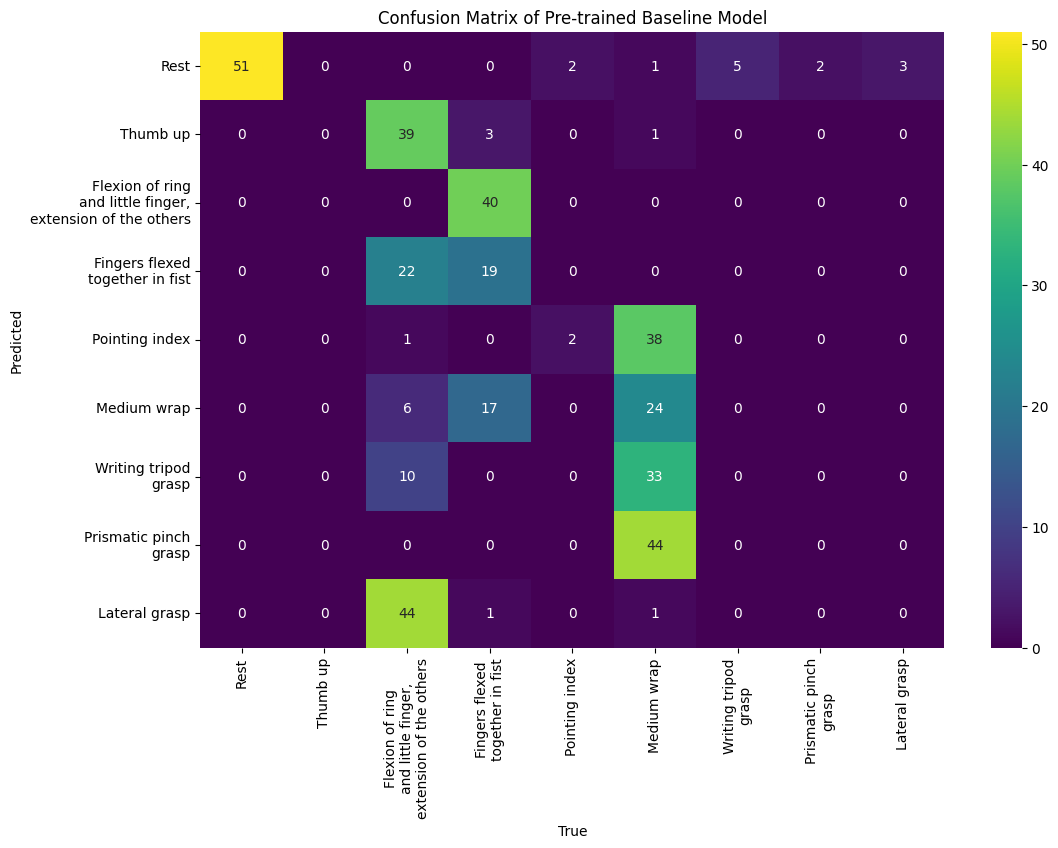

In [19]:
plt.figure(figsize=(12, 8))  # ширина=10, высота=6 дюймов
sns.heatmap(conf_matrix_real, cmap='viridis', annot=True, fmt=".0f", xticklabels=GESTURE_NAMES, yticklabels=GESTURE_NAMES)

plt.xlabel('True')
plt.ylabel('Predicted')

plt.title('Confusion Matrix of Pre-trained Baseline Model')

Для дообучения надо ставить низкий темп обучения (lr, размер батча), чтобы предотвратить разрушение претрейновых параметров и стабилизировать градиенты.

In [20]:
weights_path = '../model_finetuned/weights.h5'   
train_model(model, 500, X_train=X_train, y_train=y_train, lr=1e-2, X_valid=X_test, y_valid=y_test, 
            batch_size=32, save_path=weights_path) 

Epoch 1/500


2025-07-25 12:34:52.239118: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [954,1]
	 [[{{node Placeholder/_11}}]]
2025-07-25 12:34:52.239359: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [954,1]
	 [[{{node Placeholder/_11}}]]
2025-07-25 12:34:53.142545: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x5b4e67da91f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-07-25 12:34:53.142564: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): NVIDIA G

28/30 [===========================>..] - ETA: 0s - loss: 2.3475 - accuracy: 0.6027
Epoch 1: val_loss improved from inf to 1.39591, saving model to ../model_finetuned/weights.h5
30/30 [==============================] - 2s 11ms/step - loss: 2.3109 - accuracy: 0.6069 - val_loss: 1.3959 - val_accuracy: 0.6675
Epoch 2/500
 1/30 [>.............................] - ETA: 0s - loss: 1.4831 - accuracy: 0.6562

2025-07-25 12:34:54.521670: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [409,1]
	 [[{{node Placeholder/_11}}]]
2025-07-25 12:34:54.521875: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [409,1]
	 [[{{node Placeholder/_11}}]]


18/30 [=================>............] - ETA: 0s - loss: 0.9507 - accuracy: 0.7378
Epoch 2: val_loss improved from 1.39591 to 0.57530, saving model to ../model_finetuned/weights.h5
30/30 [==============================] - 0s 5ms/step - loss: 0.9547 - accuracy: 0.7317 - val_loss: 0.5753 - val_accuracy: 0.8557
Epoch 3/500
19/30 [==================>...........] - ETA: 0s - loss: 0.7426 - accuracy: 0.7566
Epoch 3: val_loss improved from 0.57530 to 0.28458, saving model to ../model_finetuned/weights.h5
30/30 [==============================] - 0s 5ms/step - loss: 0.7568 - accuracy: 0.7673 - val_loss: 0.2846 - val_accuracy: 0.9291
Epoch 4/500
18/30 [=================>............] - ETA: 0s - loss: 0.5510 - accuracy: 0.8403
Epoch 4: val_loss did not improve from 0.28458
30/30 [==============================] - 0s 4ms/step - loss: 0.6130 - accuracy: 0.8312 - val_loss: 0.3656 - val_accuracy: 0.9095
Epoch 5/500
19/30 [==================>...........] - ETA: 0s - loss: 0.5220 - accuracy: 0.8306
Ep

## Оценка дообученной модели

In [21]:
model.load_weights(weights_path)

In [22]:
f1_score_real, report_real, conf_matrix_real = evaluate_metrics(model, X_test, y_test)

2/2 [==============================] - 0s 2ms/step


2025-07-25 12:35:05.896026: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [409,52,8,1]
	 [[{{node Placeholder/_10}}]]
2025-07-25 12:35:05.896176: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [409,52,8,1]
	 [[{{node Placeholder/_10}}]]


In [23]:
model.evaluate(X_test, y_test)

13/13 [==============================] - 0s 1ms/step - loss: 0.1433 - accuracy: 0.9633


2025-07-25 12:35:06.013361: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [409,1]
	 [[{{node Placeholder/_11}}]]
2025-07-25 12:35:06.013526: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [409,1]
	 [[{{node Placeholder/_11}}]]


[0.14327818155288696, 0.9633252024650574]

In [24]:
print(f'F1 score: {f1_score_real}')

F1 score: 0.9615460391722741


In [25]:
for g in list(report_real.keys())[:-3]:
    print(f'Gesture #{g}')
    print('F1 score: ', report_real[g]['f1-score'])
    print('Precision: ', report_real[g]['precision'])
    print('Recall: ', report_real[g]['recall'])

Gesture #0
F1 score:  1.0
Precision:  1.0
Recall:  1.0
Gesture #1
F1 score:  0.896551724137931
Precision:  0.8863636363636364
Recall:  0.9069767441860465
Gesture #2
F1 score:  0.975609756097561
Precision:  0.9523809523809523
Recall:  1.0
Gesture #3
F1 score:  0.9647058823529412
Precision:  0.9318181818181818
Recall:  1.0
Gesture #4
F1 score:  1.0
Precision:  1.0
Recall:  1.0
Gesture #5
F1 score:  0.9782608695652174
Precision:  1.0
Recall:  0.9574468085106383
Gesture #6
F1 score:  0.9655172413793104
Precision:  0.9545454545454546
Recall:  0.9767441860465116
Gesture #7
F1 score:  0.9662921348314607
Precision:  0.9555555555555556
Recall:  0.9772727272727273
Gesture #8
F1 score:  0.9069767441860465
Precision:  0.975
Recall:  0.8478260869565217


Text(0.5, 1.0, 'Confusion Matrix of Pre-trained Baseline Model')

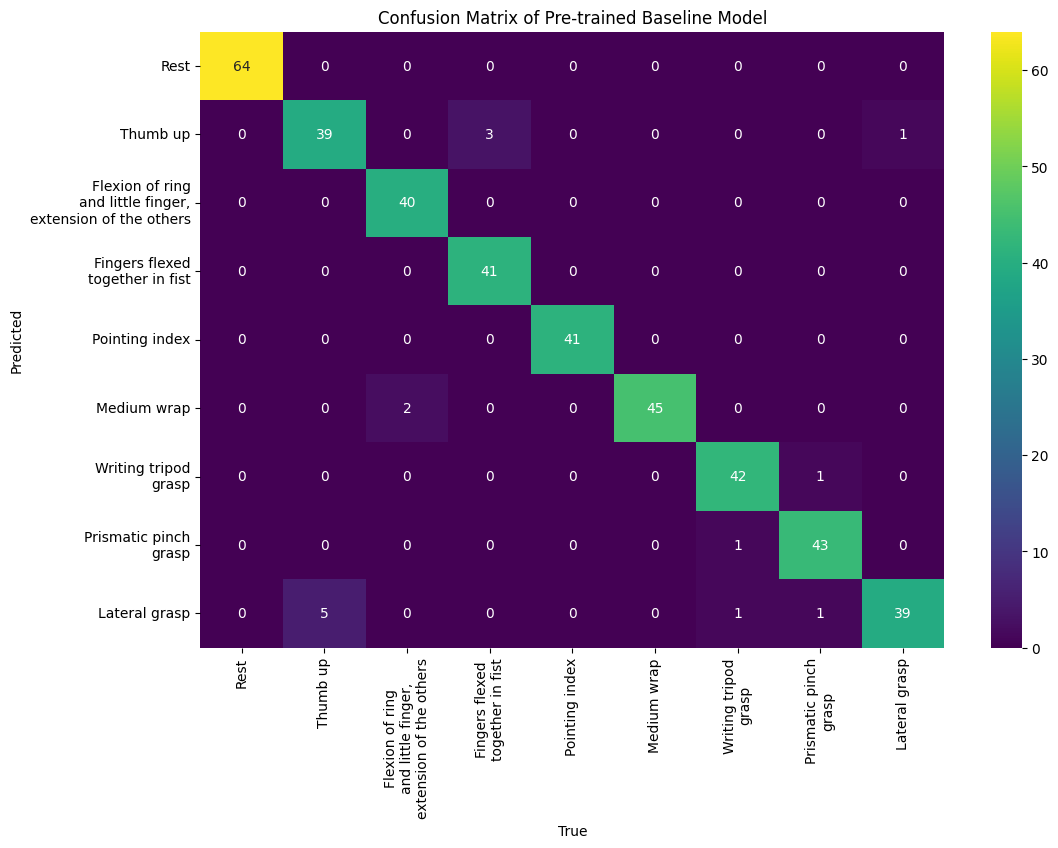

In [26]:
plt.figure(figsize=(12, 8))  # ширина=10, высота=6 дюймов
sns.heatmap(conf_matrix_real, cmap='viridis', annot=True, fmt=".0f", xticklabels=GESTURE_NAMES, yticklabels=GESTURE_NAMES)

plt.xlabel('True')
plt.ylabel('Predicted')

plt.title('Confusion Matrix of Pre-trained Baseline Model')